In [ ]:
# Cell 1 - imports & load data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pickle
import matplotlib.pyplot as plt

# Load
df = pd.read_csv('/content/diabetes.csv')
print("Shape:", df.shape)
print(df.head())
print("\nOutcome distribution:\n", df['Outcome'].value_counts())

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Outcome distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# Cell 2 - EDA focused on zeros-as-missing
cols_with_possible_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print("Counts of zeros in these columns:")
print((df[cols_with_possible_zeros] == 0).sum())

# Basic stats
display(df.describe())


Counts of zeros in these columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Cell 3 - mark zeros as NaN for medically impossible zeros
df2 = df.copy()
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for c in cols:
    df2[c] = df2[c].replace(0, np.nan)

print("Missing after replace:")
print(df2[cols].isnull().sum())


Missing after replace:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
# Cell 4 - impute with median
imputer = SimpleImputer(strategy='median')
df2[cols] = imputer.fit_transform(df2[cols])
print("Any missing left:", df2.isnull().sum().sum())


Any missing left: 0


In [ ]:
# Cell 5 - split
X = df2.drop('Outcome', axis=1)
y = df2['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# We'll create pipelines for scaling + model
scaler = StandardScaler()


Train shape: (614, 8) Test shape: (154, 8)


In [ ]:
# Cell 6 - baseline logistic regression
pipe_lr = Pipeline([
    ('scaler', scaler),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='roc_auc')
print("Logistic CV ROC-AUC (5-fold):", np.round(scores,3), "mean:", round(scores.mean(),3))

# Fit on full train set and evaluate on test
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:,1]
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba),3))
print(classification_report(y_test, y_pred))


Logistic CV ROC-AUC (5-fold): [0.866 0.84  0.852 0.847 0.816] mean: 0.844
Test ROC-AUC: 0.813
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [ ]:
# Cell 7 - Random Forest baseline
pipe_rf = Pipeline([
    ('scaler', scaler),          # scaling not essential for RF but keep consistent
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=cv, scoring='roc_auc')
print("RandomForest CV ROC-AUC (5-fold):", np.round(scores_rf,3), "mean:", round(scores_rf.mean(),3))

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:,1]
print("RF Test ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf),3))
print(classification_report(y_test, y_pred_rf))


RandomForest CV ROC-AUC (5-fold): [0.84  0.817 0.855 0.787 0.81 ] mean: 0.821
RF Test ROC-AUC: 0.815
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



In [ ]:
# Cell 8 - XGBoost (optional, pip install in Colab if not present)
# !pip install xgboost   # uncomment & run in Colab if needed

from xgboost import XGBClassifier
pipe_xgb = Pipeline([
    ('scaler', scaler),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

scores_xgb = cross_val_score(pipe_xgb, X_train, y_train, cv=cv, scoring='roc_auc')
print("XGBoost CV ROC-AUC (5-fold):", np.round(scores_xgb,3), "mean:", round(scores_xgb.mean(),3))

pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:,1]
print("XGB Test ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb),3))
print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:30:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:30:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:30:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:30:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:30:26] WARNING: /w

XGBoost CV ROC-AUC (5-fold): [0.791 0.788 0.828 0.746 0.766] mean: 0.784


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:30:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB Test ROC-AUC: 0.808
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



In [ ]:
# Cell 9 - Hyperparameter tuning for RandomForest with RandomizedSearchCV
from scipy.stats import randint, uniform
param_dist = {
    'clf__n_estimators': randint(50, 400),
    'clf__max_depth': randint(3, 20),
    'clf__min_samples_split': randint(2, 20),
    'clf__min_samples_leaf': randint(1, 10)
}

rs = RandomizedSearchCV(
    pipe_rf, param_distributions=param_dist, n_iter=40,
    scoring='roc_auc', cv=cv, random_state=42, n_jobs=-1, verbose=1
)
rs.fit(X_train, y_train)
print("Best params:", rs.best_params_)
print("Best CV ROC-AUC:", rs.best_score_)

best_rf = rs.best_estimator_
y_proba_best_rf = best_rf.predict_proba(X_test)[:,1]
print("Tuned RF Test ROC-AUC:", round(roc_auc_score(y_test, y_proba_best_rf),3))
print(classification_report(y_test, best_rf.predict(X_test)))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 17, 'clf__n_estimators': 111}
Best CV ROC-AUC: 0.8407613510520486
Tuned RF Test ROC-AUC: 0.817
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



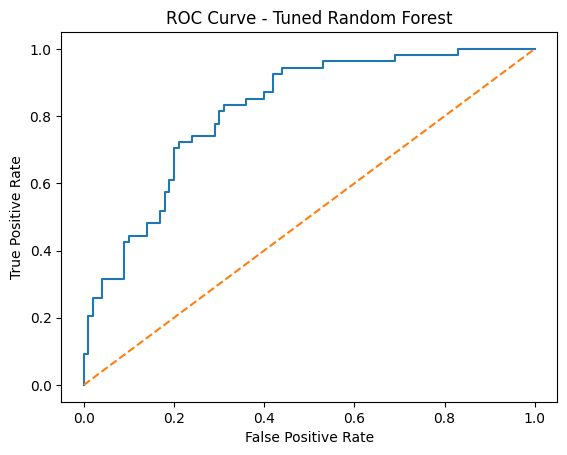

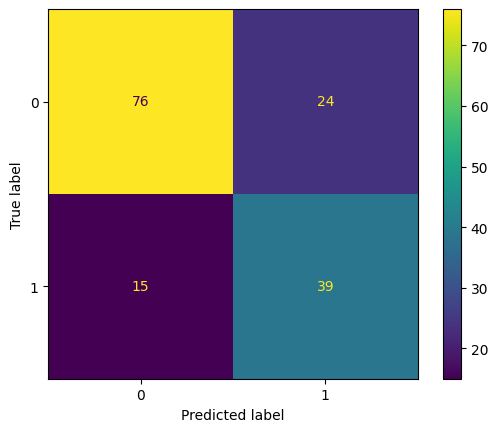

In [ ]:
# Cell 10 - ROC curve and confusion matrix for best model
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fpr, tpr, thresholds = roc_curve(y_test, y_proba_best_rf)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, best_rf.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()


In [ ]:
# Cell 11 - Save model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
print("Saved best_model.pkl")


Saved best_model.pkl


In [ ]:
# Cell 12 - Adjust threshold to improve recall if needed
probs = best_rf.predict_proba(X_test)[:,1]
threshold = 0.35  # example: lower threshold to increase recall
y_pred_thresh = (probs >= threshold).astype(int)
print("Threshold:", threshold)
print(classification_report(y_test, y_pred_thresh))


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.89      0.59      0.71       100
           1       0.53      0.87      0.66        54

    accuracy                           0.69       154
   macro avg       0.71      0.73      0.69       154
weighted avg       0.77      0.69      0.69       154

